# **Fatigue_Analysis_System_Unit(III)**

# 0. First import some formulas and functions we will be using!



*   Before starting, run the following code



In [ ]:
#@title
from google.colab import files
import plotly.graph_objects as go
import numpy as np
import pandas as pd
from scipy.signal import find_peaks


def find_peak_weird_detection(data, height, distance):
  peak_list = find_peaks(data, height=height, distance=distance)[0]
  if(peak_list.size != 0):
    print('Found a total of', peak_list.size, 'peak')
    peak_peak_list = (np.diff(peak_list))
    pp_mean = np.mean(peak_peak_list)
    counter = 0
    counter2 = 0
    counter3 = 0

    for i in peak_peak_list:
      if(i > pp_mean+100):
        counter2 = counter2 + 1

    print('Found',counter2,'[weird peak]')

    weird_peak_list_start = np.zeros(counter2,int)
    weird_peak_list_end = np.zeros(counter2,int)
    weird_pp_list = np.zeros(counter2,int)


    for i in peak_peak_list:
      if(i > pp_mean+100):
        weird_peak_list_start[counter3] = peak_list[counter]
        weird_peak_list_end[counter3] = peak_list[counter+1]
        weird_pp_list[counter3] = i
        counter3 += 1
      counter = counter + 1

    pp_mean_fixed_1 = (pp_mean*(peak_peak_list.size))
    pp_mean_fixed_2 = pp_mean_fixed_1 - np.sum(weird_pp_list)
    pp_mean_fixed = int(pp_mean_fixed_2/(peak_peak_list.size - weird_pp_list.size))

  else:
    print('Unable to find any peak, please readjust the height and distance to find the peak')

  return peak_list, peak_peak_list, weird_peak_list_start, weird_peak_list_end, pp_mean_fixed

def FourHz_resample(peak_list, peak_peak_list, pp_mean_fixed, weird_peak_list_start, weird_peak_list_end):
  peak_list_length = peak_list[peak_list.size-1] - peak_list[0]
  FourHz_size = int(peak_list_length*4/500) + 1

  FourHz_data = np.zeros(FourHz_size,float)

  pointer = peak_list[0]
  pointer_counter = 1
  counter = 0
  weird_peak_list_counter = 0

  for i in FourHz_data:
    if(pointer > peak_list[pointer_counter]):
      pointer_counter +=1

    if(pointer < weird_peak_list_start[weird_peak_list_counter]):
      FourHz_data[counter] = peak_peak_list[pointer_counter - 1]
      pointer = pointer + 125
      counter = counter + 1
    else:
      if(weird_peak_list_counter <= weird_peak_list_start.size-1):
        if(pointer < weird_peak_list_end[weird_peak_list_counter]):
          FourHz_data[counter] = pp_mean_fixed
          pointer = pointer + 125
          counter = counter + 1
        else:
          if(weird_peak_list_counter != weird_peak_list_start.size-1):
            weird_peak_list_counter += 1
            FourHz_data[counter] = peak_peak_list[pointer_counter - 1]
            pointer = pointer + 125
            counter = counter + 1
          else:
            FourHz_data[counter] = peak_peak_list[pointer_counter - 1]
            pointer = pointer + 125
            counter = counter + 1
      else: #Have handled all the weird peak
        FourHz_data[counter] = peak_peak_list[pointer_counter - 1]
        pointer = pointer + 125
        counter = counter + 1
  return FourHz_data

# 1. Enter ECG signals that satisfies the length requirement into the codebase!



*   Carefully observe heartbeat pattern. In the medical field, a valid ECG signal recording needs to be at least 5 minutes long!



In [ ]:
uploaded = files.upload()

for fn in uploaded.keys():
  print('You have uploaded','"{name}" '.format(
      name=fn, length=len(uploaded[fn])))

# 2. Try processing longer ECG signal!

Tips: Read file error is usually caused by incorrect file name. Double check the file name!

In [ ]:
#Let's read the uploaded file!
df = pd.read_csv('Sample_ECG_Signal(6min).txt') #Remember to change to your own file name!
data = np.array(df)
data2 = data[0 : , 0]

In [ ]:
#Config the figure setting!
fig = go.Figure()
fig.add_trace(go.Scatter(
    y=data2[0:5000], #Sample the first 10 seconds to help find the appropriate height and distance for find_peaks!
    mode='lines',
    name='Original Plot'
))
fig.update_layout(
    title="A section of the ECG signal",
    font=dict(
        family="Courier New, monospace",
        size=20,
        color="RebeccaPurple"
    )
)
#Display your result!
fig.show()



*   Observe the figure above to adjust the distance(x-axis) and height(y-axis) to obtain the best find_peaks performance!
*   System will tell you how much [weird peak] there are. Try to keep weird peak below 10!



---


> Tip: x-axis-What is the approximate distance between the peaks on the x-axis?






In [ ]:
height = 0.9
distance = 250
(peak_list, pp_list, weird_p_start, weird_p_end, pp_mean) = find_peak_weird_detection(data2, height, distance)

In [ ]:
#Test the detected waveform again!

#Config the figure setting!
fig = go.Figure()
fig.add_trace(go.Scatter(
    y=data2[0:5000],
    mode='lines',
    name='ECG Signal'
))

counter = 0
for i in peak_list:
  counter += 1
  if(i >= 5000):
    break

#Plot the detected peaks on the figure as well!
fig.add_trace(go.Scatter(
    x=peak_list[0:counter-1],
    y=[data2[j] for j in peak_list],
    mode='markers',
    marker=dict(
        size=8,
        color='red',
        symbol='cross'
    ),
    name='Detected Peak Position'
))
fig.update_layout(
    title="A section of ECG Signal and Peak Detection",
    font=dict(
        family="Courier New, monospace",
        size=20,
        color="RebeccaPurple"
    )
)
#Display your result！
fig.show()

# 3. Display the heartbeat pattern!

*   Observe the schematic below. The first important step is to find every peak!
*   Create a sequence using the peak intervals. Use the change in the sequence to show the heartbeat pattern!

---
> Sample sequence: (...,1000,1000,1000,1000,800,800,800,800,875,875,875,875,...)





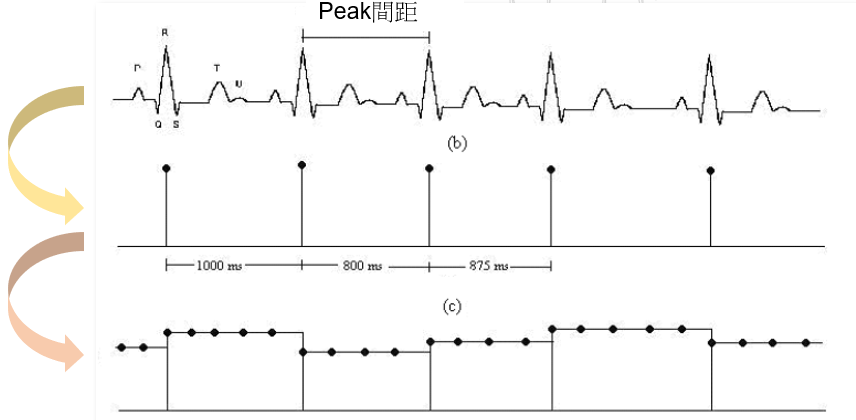


---


*(By Pierre Asselin, Relationship Between The Autonomic Nervous System and The Recovering Heart Post Exercise Using Heart Rate Variability, NJIT Masters Thesis, May 2005 - Tools by Rockland and Asselin)*

In [ ]:
#Run this code to create heartbeat sequence

FourHz_data = FourHz_resample(peak_list, pp_list, pp_mean, weird_p_start, weird_p_end)
print(FourHz_data)

# 4. Using spectrum analysis to quantify the heartbeat interval sequence!



> Use spectrum analysis on the data. Observe the distribution of heart rate variability!



In [ ]:
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

# N：Amount of data points
# T：The time interval between each data points (for 4 points per second the interval is 1/4 second)
N = FourHz_data.size
T = 1.0 / 4.0

#Following are standard expression
x = np.linspace(0.0, N*T, N, endpoint=False)
yf = fft(FourHz_data)
xf = fftfreq(N, T)[1:N//2]
yf_abs = np.abs(yf[1:N//2])
fig = go.Figure()
fig.add_trace( go.Scatter(x=xf, y=2.0/N * yf_abs))
fig.update_layout(
    title="The power spectral distribution of the entire ECG signal",
    font=dict(
        family="Courier New, monospace",
        size=20,
        color="RebeccaPurple"
    )
)
fig.show()

# 5. Separate the quantified heart beat frequency domain data into different categories!
> This is to obtain LF、HF and to calculate the primary indicator Low High Ratio (LF/HF)

> From the above spectrum, sum each heart rate variability spectrum within the given frequency range. Check the value within the range!

*   Total power(TP): 0~0.4 Hz
*   Very low frequency power(VLF): 0~0.04 Hz
*   Low frequency power(LF): 0.04~0.15 Hz
*   High frequency power(HF): 0.15~0.4 Hz


---




> Normalized and ratio's analysis data



*   Normalized LF(nLF) : LF/(TP-VLF)*100
*   Normalized HF(nHF) : HF/(TP-VLF)*100
*   Low high ratio(LHR) = LF/HF















In [ ]:
counter = 0
VLF_pointer = 0
LF_pointer = 0
HF_pointer = 0
for i in xf:
  if(i <= 0.04):
    VLF_pointer = counter
  else:
    if(i <= 0.15):
      LF_pointer = counter
    else:
      if(i <= 0.4):
        HF_pointer = counter
      else:
        break
  counter += 1

TP = 0
VLF = 0
LF = 0
HF = 0
counter = 0
for i in yf_abs:
  if(counter <= VLF_pointer):
    VLF = (2.0/N * i) + VLF
    TP = (2.0/N * i) + TP
  else:
    if(counter <= LF_pointer):
      LF = (2.0/N * i) + LF
      TP = (2.0/N * i) + TP
    else:
      if(counter <= HF_pointer):
        HF = (2.0/N * i) + HF
        TP = (2.0/N * i) + TP
      else:
        break
  counter += 1

print('TP is ',TP)
print('VLF is ',VLF)
print('LF is ',LF)
print('HF is ',HF)


nLF = LF/(TP-VLF)*100
nHF = HF/(TP-VLF)*100

print('normalized LF is ',nLF)
print('normalized HF is ',nHF)

LHR = LF/HF
print('LHR is ',LHR)


#Review of the calculation method for heart rate seen in the previous unit
heart_rate = (60/np.mean(pp_list*0.002))
print('Heart rate is', heart_rate, 'beats per minute')

# Chapter Summary


1.   To get the most real heartbeat pattern, minimize the [weird peaks]!
2.   Heartbeat interval sequence can strengthen the pattern!
3.   Spectrum analysis can be used to quantify heartbeat pattern!



# Congratulation on completing this chapter's classes



> For student that needs the class certificate you can use the password on the bookstore website to obtain it

> Certificate password: [yutechECG1]!